# Grafo de la Red Viaria de Madrid · Puntos Negros de Accidentalidad

Construye un MultiGrafo de la red de carreteras de Madrid y señaliza
los puntos negros de accidentalidad por categoría de peligrosidad.

**Salidas generadas:**
- `grafo_madrid.png` — imagen estática
- `grafo_madrid.graphml` — grafo exportado en GraphML
- `visor_grafo_madrid.html` — visor interactivo html

**Dependencias:**
```
pip install geopandas networkx matplotlib pandas scipy
```


In [1]:
import geopandas as gpd
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree
import json
import gzip
import base64

# ── Rutas de entrada ─────────────────────────────────────────────────────────
ROADS_FILE  = "carreteras-madrid.gpkg"
POINTS_FILE = "puntos_negros_nodos.csv"

# ── Parámetros ───────────────────────────────────────────────────────────────
SNAP_M     = 5   # tolerancia de snap de nodos (metros)
MAX_SNAP_M = 50  # distancia máxima para asignar un punto negro a un nodo

# ── Colores por tipo de vía ──────────────────────────────────────────────────
FCLASS_COLOR = {
    "motorway":       "#e63946",
    "motorway_link":  "#e63946",
    "trunk":          "#f4a261",
    "trunk_link":     "#f4a261",
    "primary":        "#f4a261",
    "primary_link":   "#f4a261",
    "secondary":      "#2a9d8f",
    "secondary_link": "#2a9d8f",
    "tertiary":       "#457b9d",
    "tertiary_link":  "#457b9d",
    "residential":    "#adb5bd",
    "unclassified":   "#ced4da",
}

# ── Colores puntos negros por categoría ──────────────────────────────────────
PN_COLOR = {
    "BAJO":    "#fee08b",
    "MEDIO":   "#fc8d59",
    "ALTO":    "#d73027",
    "CRITICO": "#7b2d8b",
}

# ── Mapeos numéricos para el visor HTML ──────────────────────────────────────
FCLASS_IDX = {
    "motorway": 0, "motorway_link": 1, "trunk": 2, "trunk_link": 3,
    "primary": 4, "primary_link": 5, "secondary": 6, "secondary_link": 7,
    "tertiary": 8, "tertiary_link": 9, "residential": 10, "unclassified": 11,
}
CAT_IDX = {"BAJO": 1, "MEDIO": 2, "ALTO": 3, "CRITICO": 4}




## 1 · Cargar y proyectar carreteras

In [2]:
gdf = gpd.read_file(ROADS_FILE).to_crs(epsg=25830)
print(f"  Tramos cargados: {len(gdf):,}")
gdf.head(3)


  Tramos cargados: 41,227


,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,geometry
0,3996189,5111,motorway,,M-40,F,100,0,F,F,"LINESTRING (436816.653 4468183.86, 436852.071 ..."
1,3996190,5113,primary,Rotonda de Arcentales,,B,0,0,F,F,"LINESTRING (449354.85 4475715.537, 449346.643 ..."
2,3996191,5131,motorway_link,,,F,70,0,F,F,"LINESTRING (449286.056 4475291.954, 449298.385..."


## 2 · Construir el MultiGraph

La construcción de nodos se ha vectorizado completamente con NumPy:
- Se extraen los vértices inicial y final de cada segmento con operaciones de array.
- El snap a la cuadrícula de 5 m se aplica con `np.round` sobre todos los registros a la vez.
- Los bucles degenerados (u == v) se filtran con una máscara booleana.
- Los atributos de nodo (x, y) se asignan con `nx.set_node_attributes` en una sola llamada.


In [ ]:
def snap_array(coords: np.ndarray, p: float = SNAP_M) -> np.ndarray:
    """Snap vectorizado: redondea a la cuadrícula de p metros."""
    return (np.round(coords / p) * p).astype(np.float64)



# ── Extraer coordenadas inicio/fin de todos los tramos ───────────────────────
# geometry.coords devuelve una secuencia; usamos apply para obtener arrays.
coords_start = np.array(
    gdf.geometry.apply(lambda g: g.coords[0]).tolist()
) 
coords_end = np.array(
    gdf.geometry.apply(lambda g: g.coords[-1]).tolist()
)  

# ── Snap vectorizado ──────────────────────────────────────────────────────────
u_arr = snap_array(coords_start) 
v_arr = snap_array(coords_end)   

# ── Filtrar bucles degenerados (u == v) ───────────────────────────────────────
mask_valid = ~np.all(u_arr == v_arr, axis=1)
u_arr      = u_arr[mask_valid]
v_arr      = v_arr[mask_valid]
gdf_valid  = gdf[mask_valid].reset_index(drop=True)


# ── Convertir a tuplas para usarlas como nodos de NetworkX ───────────────────
u_nodes = list(map(tuple, u_arr))
v_nodes = list(map(tuple, v_arr))

# ── Preparar atributos de arista como listas ──────────────────────────────────
fclasses  = gdf_valid["fclass"].tolist()
names     = gdf_valid["name"].fillna("").tolist()
maxspeeds = gdf_valid["maxspeed"].astype(int).tolist()
lengths   = gdf_valid.geometry.length.round(1).tolist()
oneways   = gdf_valid["oneway"].tolist()

# ── Añadir todas las aristas de una vez ──────────────────────────────────────
G = nx.MultiGraph()
G.add_edges_from(
    zip(
        u_nodes,
        v_nodes,
        (
            dict(fclass=fc, name=nm, maxspeed=ms, length_m=ln, oneway=ow)
            for fc, nm, ms, ln, ow
            in zip(fclasses, names, maxspeeds, lengths, oneways)
        ),
    )
)

# ── Asignar coordenadas a los nodos vectorizadamente ─────────────────────────
node_list = list(G.nodes())
node_arr  = np.array(node_list)           

nx.set_node_attributes(G, dict(zip(node_list, node_arr[:, 0].tolist())), "x")
nx.set_node_attributes(G, dict(zip(node_list, node_arr[:, 1].tolist())), "y")

print(f"  Nodos:           {G.number_of_nodes():>8,}")
print(f"  Aristas:         {G.number_of_edges():>8,}")
print(f"  Aristas dobles:  {sum(1 for u,v,k in G.edges(keys=True) if k>0):>8,}")



  Nodos:             41,229
  Aristas:           40,694
  Aristas dobles:       235


## 3 · Asignar puntos negros al nodo más cercano

In [4]:
df_pn = pd.read_csv(POINTS_FILE)
gdf_pn = gpd.GeoDataFrame(
    df_pn,
    geometry=gpd.points_from_xy(df_pn["lon_centro"], df_pn["lat_centro"]),
    crs="EPSG:4326",
).to_crs(epsg=25830)

# ── KDTree sobre nodos del grafo ─────────────────────────────────────────────
node_list = list(G.nodes())
node_arr  = np.array(node_list)          
tree      = cKDTree(node_arr)

pn_coords = np.column_stack([gdf_pn.geometry.x, gdf_pn.geometry.y])
dists, idx = tree.query(pn_coords)      

# ── Filtrar por distancia máxima ─────────────────────────────────────────────
valid_mask  = dists <= MAX_SNAP_M
valid_idx   = np.where(valid_mask)[0]   # índices de puntos negros válidos

# ── Construir dict node → (categoria, idx_peligrosidad) ───────────────────────
# Mantenemos el punto negro de mayor peligrosidad por nodo.
pn_nodes: dict = {}
for i in valid_idx:
    node      = node_list[idx[i]]
    row       = df_pn.iloc[i]
    cat, peli = row["categoria"], row["idx_peligrosidad"]
    if node not in pn_nodes or peli > pn_nodes[node][1]:
        pn_nodes[node] = (cat, peli)

print(f"  Puntos negros totales:  {len(df_pn):,}")
print(f"  Asignados (≤{MAX_SNAP_M} m):  {valid_mask.sum():,}")
print(f"  Nodos con punto negro:  {len(pn_nodes):,}")


  Puntos negros totales:  7,763
  Asignados (≤50 m):  6,403
  Nodos con punto negro:  6,188


## 4 · Visualización estática

Imagen guardada: grafo_madrid_con_puntos_negros.png


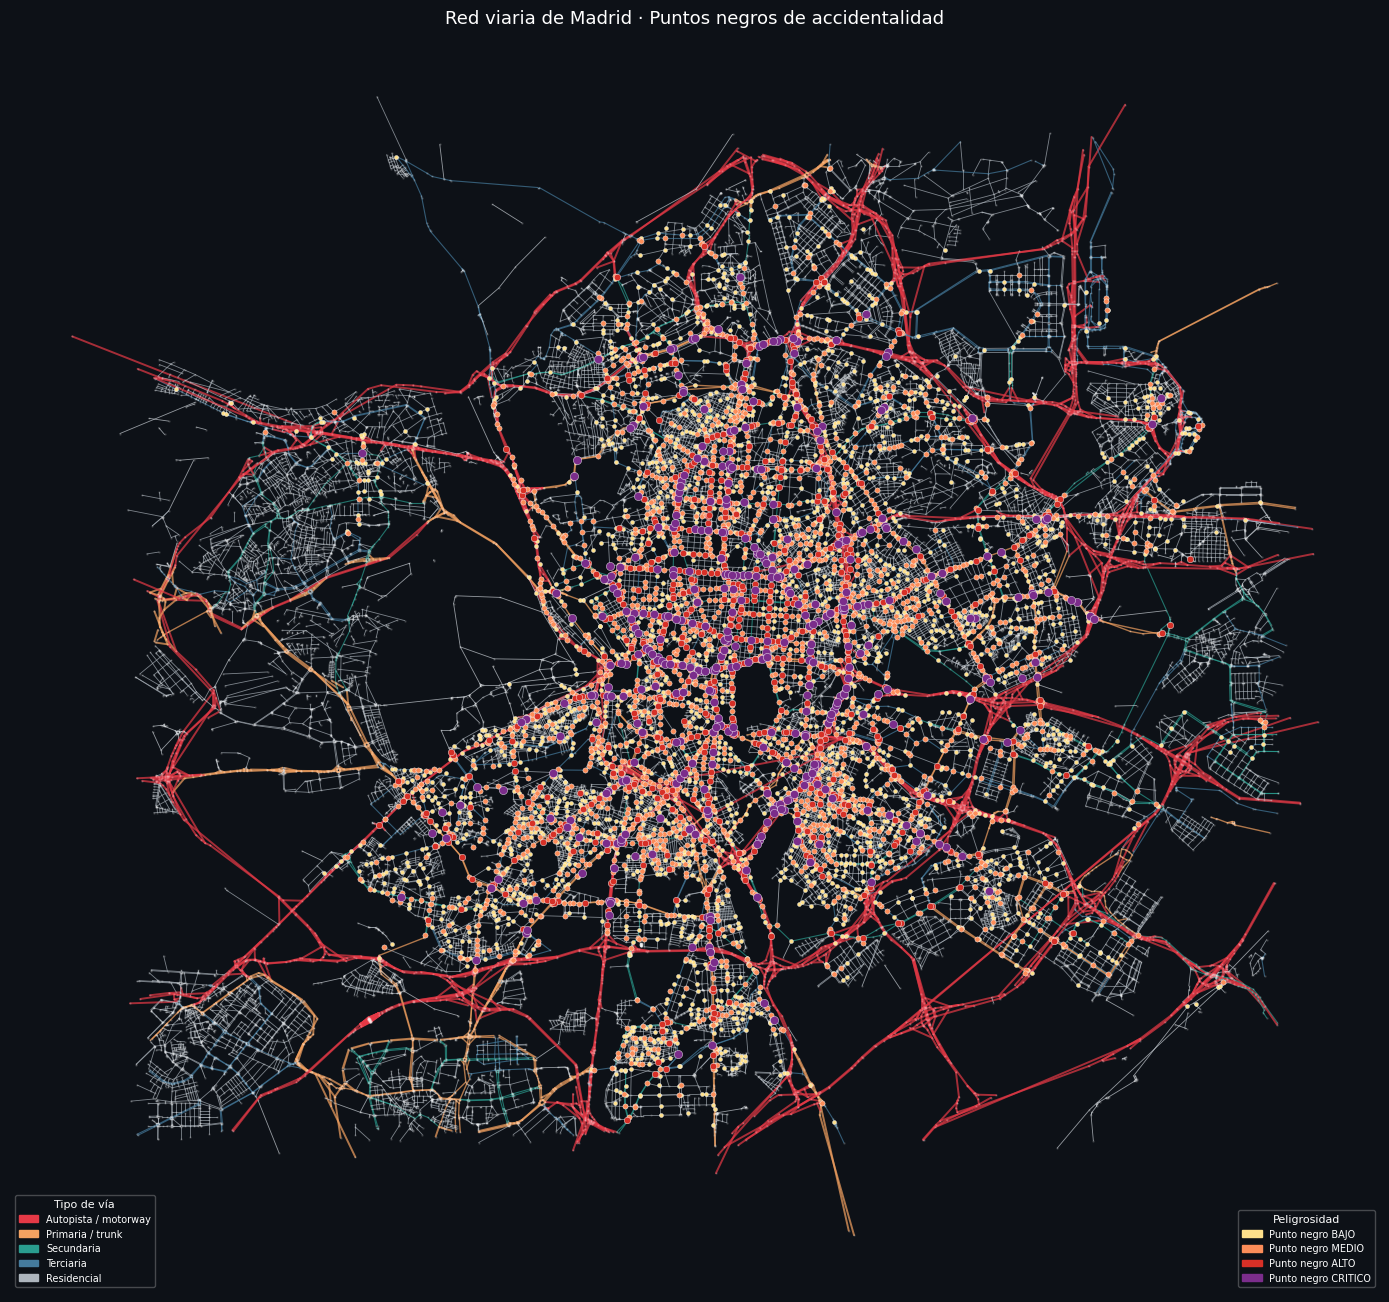

In [5]:
fig, ax = plt.subplots(figsize=(14, 14), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.set_aspect("equal")
ax.axis("off")

# ── Aristas coloreadas por tipo de vía ───────────────────────────────────────
for u, v, data in G.edges(data=True):
    fclass = data.get("fclass", "")
    color  = FCLASS_COLOR.get(fclass, "#555555")
    lw     = 0.6
    if "motorway" in fclass or "trunk" in fclass:
        lw = 1.4
    elif "primary" in fclass:
        lw = 1.0
    elif "secondary" in fclass or "tertiary" in fclass:
        lw = 0.8
    ax.plot([u[0], v[0]], [u[1], v[1]],
            color=color, lw=lw, alpha=0.7, solid_capstyle="round")

# ── Todos los nodos ──────────────────────────────────────
all_xy = np.array(list(G.nodes()))
ax.scatter(all_xy[:, 0], all_xy[:, 1], s=0.5, c="#ffffff", alpha=0.15, zorder=2)

# ── Nodos de puntos negros por categoría ─────────────────────────────────────
for cat in ["BAJO", "MEDIO", "ALTO", "CRITICO"]:
    nodes_cat = [n for n, (c, _) in pn_nodes.items() if c == cat]
    if not nodes_cat:
        continue
    xy   = np.array(nodes_cat)
    size = {"BAJO": 8, "MEDIO": 14, "ALTO": 22, "CRITICO": 35}[cat]
    ax.scatter(
        xy[:, 0], xy[:, 1],
        s=size, c=PN_COLOR[cat],
        edgecolors="white", linewidths=0.3,
        zorder=5, label=f"Punto negro {cat} ({len(nodes_cat)})",
    )

# ── Leyenda vías ─────────────────────────────────────────────────────────────
road_patches = [
    mpatches.Patch(color="#e63946", label="Autopista / motorway"),
    mpatches.Patch(color="#f4a261", label="Primaria / trunk"),
    mpatches.Patch(color="#2a9d8f", label="Secundaria"),
    mpatches.Patch(color="#457b9d", label="Terciaria"),
    mpatches.Patch(color="#adb5bd", label="Residencial"),
]
leg1 = ax.legend(
    handles=road_patches, loc="lower left",
    framealpha=0.3, facecolor="#0d1117", labelcolor="white",
    fontsize=7, title="Tipo de vía", title_fontsize=8,
)
leg1.get_title().set_color("white")
ax.add_artist(leg1)

# ── Leyenda puntos negros ─────────────────────────────────────────────────────
pn_patches = [
    mpatches.Patch(color=PN_COLOR[c], label=f"Punto negro {c}") for c in PN_COLOR
]
leg2 = ax.legend(
    handles=pn_patches, loc="lower right",
    framealpha=0.3, facecolor="#0d1117", labelcolor="white",
    fontsize=7, title="Peligrosidad", title_fontsize=8,
)
leg2.get_title().set_color("white")

ax.set_title(
    "Red viaria de Madrid · Puntos negros de accidentalidad",
    color="white", fontsize=13, pad=12,
)

plt.tight_layout()
plt.savefig("grafo_madrid_con_puntos_negros.png", dpi=180,
            bbox_inches="tight", facecolor=fig.get_facecolor())
print("Imagen guardada: grafo_madrid_con_puntos_negros.png")
plt.show()


## 5 · Exportar grafo a GraphML

In [6]:
nx.write_graphml(G, "grafo_magrafo_madrid_con_puntos_negrosdrid.graphml")
print("Grafo exportado: grafo_madrid_con_puntos_negros.graphml")


Grafo exportado: grafo_madrid_con_puntos_negros.graphml


## 6 · Generar visor HTML interactivo

In [7]:
# ── Normalizar coordenadas a [0, 1] ──────────────────────────────────────────
node_list = list(G.nodes())
node_arr  = np.array(node_list)                        

min_x, min_y = node_arr[:, 0].min(), node_arr[:, 1].min()
max_x, max_y = node_arr[:, 0].max(), node_arr[:, 1].max()
rx, ry = max_x - min_x, max_y - min_y

nx_ = np.round((node_arr[:, 0] - min_x) / rx, 5).tolist()
ny_ = np.round((node_arr[:, 1] - min_y) / ry, 5).tolist()

# ── Grado de cada nodo (vectorizado) ─────────────────────────────────────────
degree_map = dict(G.degree())
nd_ = [degree_map[n] for n in node_list]

# ── Categoría de punto negro por nodo ────────────────────────────────────────
np_ = [CAT_IDX.get(pn_nodes[n][0], 0) if n in pn_nodes else 0 for n in node_list]

# ── Info adicional del punto negro más peligroso ──────────────────────────────
ni_ = []
for n in node_list:
    if n in pn_nodes:
        cat, idx_p = pn_nodes[n]
        row_pn = (df_pn[df_pn["categoria"] == cat]
                  .sort_values("idx_peligrosidad", ascending=False)
                  .iloc[0])
        ni_.append([
            int(row_pn["n_accidentes"]),
            int(row_pn["n_graves"]),
            int(row_pn["n_mortales"]),
            round(float(idx_p), 3),
        ])
    else:
        ni_.append(None)

# ── Arrays de aristas ─────────────────────────────────────────────────────────
node_idx_map = {n: i for i, n in enumerate(node_list)}

edges_data = list(G.edges(data=True))
eu_ = [node_idx_map[u]                                  for u, v, _ in edges_data]
ev_ = [node_idx_map[v]                                  for u, v, _ in edges_data]
ef_ = [FCLASS_IDX.get(d.get("fclass",""), 10)           for _, _, d in edges_data]
es_ = [int(d.get("maxspeed", 0))                        for _, _, d in edges_data]
el_ = [float(d.get("length_m", 0))                      for _, _, d in edges_data]
en_ = [d.get("name","") or ""                           for _, _, d in edges_data]

# ── Serializar y comprimir ────────────────────────────────────────────────────
graph_data = dict(nx=nx_, ny=ny_, nd=nd_, np=np_, ni=ni_,
                  eu=eu_, ev=ev_, ef=ef_, es=es_, el=el_, en=en_)
raw_json   = json.dumps(graph_data, separators=(",", ":"))
compressed = gzip.compress(raw_json.encode(), compresslevel=9)
b64_data   = base64.b64encode(compressed).decode()
print(f"  Datos: {len(raw_json)/1e6:.1f} MB -> comprimido+b64: {len(b64_data)/1e6:.2f} MB")


  Datos: 2.9 MB -> comprimido+b64: 0.86 MB


In [8]:
HTML_TEMPLATE = """<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<title>Grafo Red Viaria Madrid</title>
<style>
* { margin:0; padding:0; box-sizing:border-box; }
body { background:#0d1117; color:#e6edf3; font-family:monospace; overflow:hidden; }
#canvas { display:block; cursor:grab; }
#canvas.grabbing { cursor:grabbing; }
#info {
  position:fixed; top:12px; left:12px; background:rgba(13,17,23,0.85);
  border:1px solid #30363d; border-radius:8px; padding:12px 16px;
  font-size:11px; line-height:1.7; max-width:220px; backdrop-filter:blur(4px);
}
#info h2 { font-size:13px; margin-bottom:6px; color:#58a6ff; }
#tooltip {
  position:fixed; display:none; background:rgba(13,17,23,0.95);
  border:1px solid #58a6ff; border-radius:6px; padding:10px 14px;
  font-size:11px; line-height:1.8; pointer-events:none; max-width:240px;
  backdrop-filter:blur(4px);
}
#legend {
  position:fixed; bottom:12px; left:12px; background:rgba(13,17,23,0.85);
  border:1px solid #30363d; border-radius:8px; padding:10px 14px;
  font-size:10px; backdrop-filter:blur(4px);
}
#legend h3 { font-size:11px; color:#8b949e; margin-bottom:6px; }
.leg-row { display:flex; align-items:center; gap:6px; margin-bottom:3px; }
.leg-color { width:24px; height:3px; border-radius:2px; }
.leg-dot { width:10px; height:10px; border-radius:50%; border:1px solid rgba(255,255,255,0.4); }
#controls {
  position:fixed; top:12px; right:12px; display:flex; flex-direction:column; gap:6px;
}
button {
  background:#21262d; border:1px solid #30363d; color:#e6edf3;
  padding:6px 12px; border-radius:6px; cursor:pointer; font-size:11px; font-family:monospace;
}
button:hover { background:#30363d; }
#search {
  background:#21262d; border:1px solid #30363d; color:#e6edf3;
  padding:6px 10px; border-radius:6px; font-size:11px; font-family:monospace;
  width:160px; outline:none;
}
#search:focus { border-color:#58a6ff; }
</style>
</head>
<body>
<canvas id="canvas"></canvas>
<div id="info">
  <h2>&#x1F5FA; Red Viaria Madrid</h2>
  <div id="stats">Cargando datos...</div>
  <div style="margin-top:8px;color:#8b949e;font-size:10px;">
    &#x1F5B1; Rueda: zoom &middot; Arrastrar: mover<br>
    Clic en nodo: detalles
  </div>
</div>
<div id="tooltip"></div>
<div id="legend">
  <h3>TIPO DE V&Iacute;A</h3>
  <div class="leg-row"><div class="leg-color" style="background:#e63946"></div>Autopista</div>
  <div class="leg-row"><div class="leg-color" style="background:#f4a261"></div>Primaria / Trunk</div>
  <div class="leg-row"><div class="leg-color" style="background:#2a9d8f"></div>Secundaria</div>
  <div class="leg-row"><div class="leg-color" style="background:#457b9d"></div>Terciaria</div>
  <div class="leg-row"><div class="leg-color" style="background:#6e7681"></div>Residencial / Otras</div>
  <h3 style="margin-top:8px;">PUNTO NEGRO</h3>
  <div class="leg-row"><div class="leg-dot" style="background:#fee08b"></div>BAJO</div>
  <div class="leg-row"><div class="leg-dot" style="background:#fc8d59"></div>MEDIO</div>
  <div class="leg-row"><div class="leg-dot" style="background:#d73027"></div>ALTO</div>
  <div class="leg-row"><div class="leg-dot" style="background:#9b30ff"></div>CR&Iacute;TICO</div>
</div>
<div id="controls">
  <input id="search" type="text" placeholder="Buscar calle...">
  <button onclick="resetView()">&#x27F3; Reset vista</button>
  <button onclick="togglePN()">&#x1F441; Solo puntos negros</button>
</div>
<script>
const B64 = "%%B64%%";

async function decompressB64(b64) {
  const bin = atob(b64);
  const bytes = new Uint8Array(bin.length);
  for (let i = 0; i < bin.length; i++) bytes[i] = bin.charCodeAt(i);
  const ds = new DecompressionStream('gzip');
  const writer = ds.writable.getWriter();
  writer.write(bytes); writer.close();
  const chunks = [], reader = ds.readable.getReader();
  while (true) {
    const {done, value} = await reader.read();
    if (done) break;
    chunks.push(value);
  }
  const total = chunks.reduce((a,c) => a + c.length, 0);
  const result = new Uint8Array(total);
  let offset = 0;
  for (const c of chunks) { result.set(c, offset); offset += c.length; }
  return JSON.parse(new TextDecoder().decode(result));
}

const canvas = document.getElementById('canvas');
const ctx = canvas.getContext('2d');
let W, H;
function resize() { W = canvas.width = window.innerWidth; H = canvas.height = window.innerHeight; draw(); }
window.addEventListener('resize', resize);

let ox = 0, oy = 0, scale = 1;
let dragging = false, lastMX, lastMY;
let showOnlyPN = false;
let G = null;

const FCLASS_COLOR = ['#e63946','#e63946','#f4a261','#f4a261','#f4a261','#f4a261',
                      '#2a9d8f','#2a9d8f','#457b9d','#457b9d','#6e7681','#6e7681'];
const FCLASS_LW    = [1.8,1.4,1.4,1.2,1.2,1.0,0.9,0.9,0.8,0.8,0.5,0.5];
const PN_COLOR     = [null,'#fee08b','#fc8d59','#d73027','#9b30ff'];
const PN_SIZE      = [0,1.5,1.5,1.5,1.5];
const CAT_LABEL    = ['','Bajo','Medio','Alto','Critico'];
const FCLASS_NAMES = ['Autopista','Autopista enlace','Trunk','Trunk enlace',
  'Primaria','Primaria enlace','Secundaria','Secundaria enlace',
  'Terciaria','Terciaria enlace','Residencial','Sin clasificar'];

function toScreen(nx, ny) { return [ox + nx * scale, oy + (1 - ny) * scale]; }

function draw() {
  if (!G) return;
  ctx.clearRect(0, 0, W, H);
  ctx.fillStyle = '#0d1117'; ctx.fillRect(0, 0, W, H);
  const {nx, ny, nd, np, eu, ev, ef, es, el, en} = G;

  if (!showOnlyPN) {
    const byFC = Array.from({length: 12}, () => []);
    for (let i = 0; i < eu.length; i++) byFC[ef[i]].push(i);
    for (let fc = 11; fc >= 0; fc--) {
      ctx.strokeStyle = FCLASS_COLOR[fc];
      ctx.lineWidth = FCLASS_LW[fc] * Math.max(0.4, Math.min(2, scale / 600));
      ctx.globalAlpha = 0.75;
      ctx.beginPath();
      for (const i of byFC[fc]) {
        const [x1,y1] = toScreen(nx[eu[i]], ny[eu[i]]);
        const [x2,y2] = toScreen(nx[ev[i]], ny[ev[i]]);
        if (x1 < -50 && x2 < -50) continue;
        if (x1 > W+50 && x2 > W+50) continue;
        if (y1 < -50 && y2 < -50) continue;
        if (y1 > H+50 && y2 > H+50) continue;
        ctx.moveTo(x1,y1); ctx.lineTo(x2,y2);
      }
      ctx.stroke();
    }
    ctx.globalAlpha = 1;
    if (scale > 800) {
      ctx.fillStyle = 'rgba(255,255,255,0.25)';
      for (let i = 0; i < nx.length; i++) {
        if (np[i] > 0) continue;
        const [x,y] = toScreen(nx[i], ny[i]);
        if (x < 0 || x > W || y < 0 || y > H) continue;
        ctx.beginPath(); ctx.arc(x,y,1.5,0,Math.PI*2); ctx.fill();
      }
    }
  }

  for (let cat = 1; cat <= 4; cat++) {
    const r = PN_SIZE[cat] * Math.max(0.5, Math.min(2.5, scale / 500));
    for (let i = 0; i < nx.length; i++) {
      if (np[i] !== cat) continue;
      const [x,y] = toScreen(nx[i], ny[i]);
      if (x < -20 || x > W+20 || y < -20 || y > H+20) continue;
      ctx.beginPath(); ctx.arc(x,y,r,0,Math.PI*2);
      ctx.fillStyle = PN_COLOR[cat]; ctx.fill();
      ctx.strokeStyle = 'rgba(255,255,255,0.5)'; ctx.lineWidth = 0.5; ctx.stroke();
    }
  }
}

canvas.addEventListener('wheel', e => {
  e.preventDefault();
  const f = e.deltaY < 0 ? 1.15 : 0.87;
  ox = e.clientX - (e.clientX - ox) * f;
  oy = e.clientY - (e.clientY - oy) * f;
  scale *= f; draw();
}, {passive: false});

canvas.addEventListener('mousedown', e => { dragging=true; lastMX=e.clientX; lastMY=e.clientY; canvas.classList.add('grabbing'); });
canvas.addEventListener('mousemove', e => {
  if (!dragging) return;
  ox += e.clientX-lastMX; oy += e.clientY-lastMY;
  lastMX=e.clientX; lastMY=e.clientY; draw();
});
canvas.addEventListener('mouseup',    () => { dragging=false; canvas.classList.remove('grabbing'); });
canvas.addEventListener('mouseleave', () => { dragging=false; canvas.classList.remove('grabbing'); });

canvas.addEventListener('click', e => {
  if (!G) return;
  const {nx, ny, nd, np, ni, eu, ev, ef, es, el, en} = G;
  let bestDist=20, bestI=-1;
  for (let i=0; i<nx.length; i++) {
    const [x,y] = toScreen(nx[i],ny[i]);
    const d = Math.hypot(x-e.clientX, y-e.clientY);
    if (d < bestDist) { bestDist=d; bestI=i; }
  }
  const tip = document.getElementById('tooltip');
  if (bestI < 0) { tip.style.display='none'; return; }
  const connected = [];
  for (let j=0; j<eu.length; j++) {
    if (eu[j]===bestI || ev[j]===bestI)
      connected.push({name:en[j], fclass:ef[j], speed:es[j], len:el[j]});
  }
  let html = `<b>Nodo #${bestI}</b> &middot; Grado: ${nd[bestI]}<br>`;
  if (np[bestI] > 0) {
    const info = ni[bestI];
    html += `<span style="color:${PN_COLOR[np[bestI]]}">&#x26A0; Punto negro ${CAT_LABEL[np[bestI]]}</span><br>`;
    if (info) html += `Accidentes: ${info[0]} &middot; Graves: ${info[1]} &middot; Mortales: ${info[2]}<br>Peligrosidad: ${info[3]}<br>`;
  }
  html += `<hr style="border-color:#30363d;margin:6px 0"><b>Aristas (${connected.length}):</b><br>`;
  for (const edge of connected.slice(0,6)) {
    const spd = edge.speed > 0 ? ` &middot; ${edge.speed} km/h` : '';
    html += `<span style="color:${FCLASS_COLOR[edge.fclass]}">&#x25CF;</span> ${edge.name||('sin nombre')} <i>(${FCLASS_NAMES[edge.fclass]}${spd} &middot; ${edge.len}m)</i><br>`;
  }
  if (connected.length > 6) html += `<i>...y ${connected.length-6} m&aacute;s</i>`;
  tip.innerHTML = html;
  tip.style.display = 'block';
  tip.style.left = (e.clientX+14)+'px';
  tip.style.top  = Math.min(e.clientY, H-200)+'px';
});

document.addEventListener('keydown', e => {
  if (e.key==='Escape') document.getElementById('tooltip').style.display='none';
});

document.getElementById('search').addEventListener('input', e => {
  const q = e.target.value.toLowerCase().trim();
  if (!q || !G) return;
  for (let i=0; i<G.eu.length; i++) {
    if ((G.en[i]||''). toLowerCase().includes(q)) {
      const ni = G.eu[i];
      if (scale < 2000) scale = 3000;
      ox = W/2 - G.nx[ni] * scale;
      oy = H/2 - (1 - G.ny[ni]) * scale;
      draw(); break;
    }
  }
});

function resetView() {
  if (!G) return;
  scale = Math.min(W-80, H-80);
  ox = 40; oy = 40; draw();
}
function togglePN() {
  showOnlyPN = !showOnlyPN;
  document.querySelector('#controls button:last-child').textContent =
    showOnlyPN ? '&#x1F5FA; Ver todo' : '&#x1F441; Solo puntos negros';
  draw();
}

W = canvas.width = window.innerWidth;
H = canvas.height = window.innerHeight;
document.getElementById('stats').textContent = 'Descomprimiendo datos...';
decompressB64(B64).then(data => {
  G = data;
  document.getElementById('stats').innerHTML =
    `Nodos: <b>${G.nx.length.toLocaleString()}</b><br>` +
    `Aristas: <b>${G.eu.length.toLocaleString()}</b><br>` +
    `Puntos negros: <b>${G.np.filter(x=>x>0).length.toLocaleString()}</b>`;
  resetView();
}).catch(err => {
  document.getElementById('stats').textContent = 'Error: ' + err.message;
});
</script>
</body>
</html>"""

html_out = HTML_TEMPLATE.replace("%%B64%%", b64_data)
with open("visor_grafo_madrid.html", "w", encoding="utf-8") as f:
    f.write(html_out)
print(f" Visor HTML guardado: visor_grafo_madrid.html ({len(html_out)/1e6:.2f} MB)")


 Visor HTML guardado: visor_grafo_madrid.html (0.87 MB)


## 7 · Estadísticas del grafo

In [ ]:
degrees = np.array([d for _, d in G.degree()])

stats = {
    "Nodos totales":             G.number_of_nodes(),
    "Aristas totales":           G.number_of_edges(),
    "Aristas paralelas":         sum(1 for u,v,k in G.edges(keys=True) if k > 0),
    "Grado medio":               round(float(np.mean(degrees)), 2),
    "Grado máximo":              int(degrees.max()),
    "Nodos intersección (≥ 3)":  int((degrees >= 3).sum()),
    "Nodos extremo (= 1)":       int((degrees == 1).sum()),
    "Componentes conexas":       nx.number_connected_components(G),
    "Nodos con punto negro":     len(pn_nodes),
}

print("─" * 50)
print("  Estadísticas del grafo")
print("─" * 50)
for k, v in stats.items():
    print(f"  {k:<30} {v:>10,}" if isinstance(v, int) else f"  {k:<30} {v:>10}")
print("─" * 50)

# Tabla también como DataFrame 
pd.DataFrame(stats.items(), columns=["Métrica", "Valor"])


──────────────────────────────────────────────────
  Estadísticas del grafo
──────────────────────────────────────────────────
  Nodos totales                      41,229
  Aristas totales                    40,694
  Aristas paralelas                     235
  Grado medio                          1.97
  Grado máximo                           10
  Nodos intersección (≥ 3)           13,695
  Nodos extremo (= 1)                18,012
  Componentes conexas                 6,466
  Nodos con punto negro               6,188
──────────────────────────────────────────────────


,Métrica,Valor
0,Nodos totales,41229.00
1,Aristas totales,40694.00
2,Aristas paralelas,235.00
3,Grado medio,1.97
4,Grado máximo,10.00
5,Nodos intersección (≥ 3),13695.00
6,Nodos extremo (= 1),18012.00
7,Componentes conexas,6466.00
8,Nodos con punto negro,6188.00
